### 필요 라이브러리

In [1]:
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

warnings.filterwarnings("ignore")

SEED = 42

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

set_seed(SEED)

RAW_DIR = r"C:\dev\project\project02\Data\raw_data_25000"
OUT_DIR = r"C:\dev\project\project02\Data\total_data_25000"

TRAIN_PATH = os.path.join(RAW_DIR, "train_members_v2.csv")
TX_PATH = os.path.join(RAW_DIR, "transactions_v2.csv")
LOG_PATH = os.path.join(RAW_DIR, "user_logs_aug_v2.csv")

os.makedirs(OUT_DIR, exist_ok=True)


### 데이터 로드

In [2]:

train_members_raw = pd.read_csv(TRAIN_PATH)
transactions_raw = pd.read_csv(TX_PATH)
user_logs_raw = pd.read_csv(LOG_PATH)

print("train_members_raw:", train_members_raw.shape)
print("transactions_raw:", transactions_raw.shape)
print("user_logs_raw:", user_logs_raw.shape)

display(train_members_raw.head(2))
display(transactions_raw.head(2))
display(user_logs_raw.head(2))


train_members_raw: (25000, 7)
transactions_raw: (156501, 9)
user_logs_raw: (2957909, 9)


,msno,is_churn,city,bd,gender,registered_via,registration_init_time
0,Rg+vzyy44E3SOow1HOOfkmZWrFUC8QpfILf9xOL0JWo=,0,13,41,male,3,2012-06-26
1,Ph0te4c5/kLNJwHASQjGMWg9XIVCC4gR03ke7Kq6nOA=,0,1,0,male,3,2014-12-02


,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
0,N70I6H8cJAHTwynf8YntWKJN5pWmA5hfplK3/Qaq5bY=,41,30,149,149,1,2017-02-15,2017-03-15,0
1,q7zVHl6rWbLoKUj3FCHSjO2caWkhhKskVfxPRyLBOHo=,36,30,180,180,1,2016-09-08,2016-09-07,1


,msno,date,num_25,num_50,num_75,num_985,num_100,num_unq,total_secs
0,XrnbZbpoCa4iaU+T5cgQZB4RjxvbemQCzZ/aA7KkDV4=,2016-10-07,2,1,0,0,16,17,4523.678
1,XrnbZbpoCa4iaU+T5cgQZB4RjxvbemQCzZ/aA7KkDV4=,2016-11-27,22,4,5,5,77,84,22643.762


# train_members data

In [3]:
train_members_raw.shape

(25000, 7)

In [4]:
train_members_raw.columns.tolist()

['msno',
 'is_churn',
 'city',
 'bd',
 'gender',
 'registered_via',
 'registration_init_time']

In [5]:
print("train_members_raw msno nunique:", train_members_raw["msno"].nunique())
display(train_members_raw.head(5))

train_members_raw msno nunique: 25000


,msno,is_churn,city,bd,gender,registered_via,registration_init_time
0,Rg+vzyy44E3SOow1HOOfkmZWrFUC8QpfILf9xOL0JWo=,0,13,41,male,3,2012-06-26
1,Ph0te4c5/kLNJwHASQjGMWg9XIVCC4gR03ke7Kq6nOA=,0,1,0,male,3,2014-12-02
2,b2Z7Z9hoeYycBOpXf6ufUOQM5lDqNlTXIAVMNlwfico=,0,13,31,female,9,2010-05-22
3,X6Y+vPdhcfPcX8w3KewkxxSax2c9qPvXwMwT10mAXHY=,0,13,40,female,9,2012-10-25
4,Q7mDzR0zX00sZdoIQGy1XNBFm02k18oSYpxIAkwlI/Y=,0,22,20,male,9,2015-05-20


In [6]:
train_members_raw.info()
print("\n[missing values]")
display(train_members_raw.isnull().sum().sort_values(ascending=False))
print("train duplicated msno:", train_members_raw["msno"].duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   msno                    25000 non-null  str  
 1   is_churn                25000 non-null  int64
 2   city                    25000 non-null  int64
 3   bd                      25000 non-null  int64
 4   gender                  25000 non-null  str  
 5   registered_via          25000 non-null  int64
 6   registration_init_time  25000 non-null  str  
dtypes: int64(4), str(3)
memory usage: 1.3 MB

[missing values]


msno                      0
is_churn                  0
city                      0
bd                        0
gender                    0
registered_via            0
registration_init_time    0
dtype: int64

train duplicated msno: 0


In [7]:
print("members registration range:", train_members_raw["registration_init_time"].min(), "~", train_members_raw["registration_init_time"].max())
display(train_members_raw["bd"].describe().round(4))
display(train_members_raw["city"].value_counts(dropna=False).head(20))
display(train_members_raw["gender"].value_counts(dropna=False))
display(train_members_raw["registered_via"].value_counts(dropna=False))

members registration range: 2004-03-26 ~ 2017-03-31


count    25000.0000
mean        29.2019
std         18.3856
min          0.0000
25%         23.0000
50%         28.0000
75%         34.0000
max       1970.0000
Name: bd, dtype: float64

city
13    5728
5     4011
4     2683
15    2423
22    2393
6     1563
14    1207
1      880
12     621
11     561
9      493
8      463
18     460
10     363
17     329
21     300
3      275
7      149
16      52
20      37
Name: count, dtype: int64

gender
male      13185
female    11815
Name: count, dtype: int64

registered_via
9     12798
3      5675
7      4719
4      1788
13       20
Name: count, dtype: int64

# transactions data

In [8]:
transactions_raw.shape

(156501, 9)

In [9]:
transactions_raw.columns.tolist()

['msno',
 'payment_method_id',
 'payment_plan_days',
 'plan_list_price',
 'actual_amount_paid',
 'is_auto_renew',
 'transaction_date',
 'membership_expire_date',
 'is_cancel']

In [10]:
print("transactions_raw msno nunique:", transactions_raw["msno"].nunique())
display(transactions_raw.head(5))

transactions_raw msno nunique: 24756


,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
0,N70I6H8cJAHTwynf8YntWKJN5pWmA5hfplK3/Qaq5bY=,41,30,149,149,1,2017-02-15,2017-03-15,0
1,q7zVHl6rWbLoKUj3FCHSjO2caWkhhKskVfxPRyLBOHo=,36,30,180,180,1,2016-09-08,2016-09-07,1
2,wc41UMo4ELmSVwjcDu/WxiHkQ8aqPlhA/j/gDSkdyJA=,40,30,149,149,1,2016-10-19,2016-11-19,0
3,erPBTa2ewkHfvcL89+fvRlGGCgazY/20H0ROmTIUX9Y=,40,30,149,149,1,2016-09-25,2016-11-01,0
4,RE/kFsr/Rt+6xRlndvnuPifmBqYR74mi3/vCRXrQFG4=,30,30,100,100,1,2017-01-21,2017-02-20,0


In [11]:
transactions_raw.info()
print("\n[missing values]")
display(transactions_raw.isnull().sum().sort_values(ascending=False))
print("transactions transaction_date range:", transactions_raw["transaction_date"].min(), "~", transactions_raw["transaction_date"].max())
print("transactions membership_expire_date range:", transactions_raw["membership_expire_date"].min(), "~", transactions_raw["membership_expire_date"].max())

<class 'pandas.DataFrame'>
RangeIndex: 156501 entries, 0 to 156500
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   msno                    156501 non-null  str  
 1   payment_method_id       156501 non-null  int64
 2   payment_plan_days       156501 non-null  int64
 3   plan_list_price         156501 non-null  int64
 4   actual_amount_paid      156501 non-null  int64
 5   is_auto_renew           156501 non-null  int64
 6   transaction_date        156501 non-null  str  
 7   membership_expire_date  156501 non-null  str  
 8   is_cancel               156501 non-null  int64
dtypes: int64(6), str(3)
memory usage: 10.7 MB

[missing values]


msno                      0
payment_method_id         0
payment_plan_days         0
plan_list_price           0
actual_amount_paid        0
is_auto_renew             0
transaction_date          0
membership_expire_date    0
is_cancel                 0
dtype: int64

transactions transaction_date range: 2016-09-01 ~ 2017-03-31
transactions membership_expire_date range: 1970-01-01 ~ 2021-09-06


In [12]:
display(transactions_raw[["payment_plan_days", "plan_list_price", "actual_amount_paid"]].describe().round(4))
for col in ["payment_method_id", "is_auto_renew", "is_cancel"]:
    print(f"\n[{col}]")
    display(transactions_raw[col].value_counts(dropna=False).head(20))

,payment_plan_days,plan_list_price,actual_amount_paid
count,156501.0000,156501.0000,156501.0000
mean,31.6143,153.2935,152.6783
std,20.0926,82.5284,83.0229
min,1.0000,0.0000,0.0000
25%,30.0000,149.0000,149.0000
50%,30.0000,149.0000,149.0000
75%,30.0000,149.0000,149.0000
max,450.0000,1788.0000,1788.0000



[payment_method_id]


payment_method_id
41    29827
39    26445
40    26165
36    16091
37    14142
38    12187
34    11626
33     5670
29     3910
31     3893
30     1713
27      734
32      720
35      607
23      602
28      435
19      384
21      365
16      221
14      181
Name: count, dtype: int64


[is_auto_renew]


is_auto_renew
1    134415
0     22086
Name: count, dtype: int64


[is_cancel]


is_cancel
0    153471
1      3030
Name: count, dtype: int64

# user_logs_aug data

In [13]:
user_logs_raw.shape

(2957909, 9)

In [14]:
user_logs_raw.columns.tolist()

['msno',
 'date',
 'num_25',
 'num_50',
 'num_75',
 'num_985',
 'num_100',
 'num_unq',
 'total_secs']

In [15]:
print("user_logs_raw msno nunique:", user_logs_raw["msno"].nunique())
display(user_logs_raw.head(5))

user_logs_raw msno nunique: 24408


,msno,date,num_25,num_50,num_75,num_985,num_100,num_unq,total_secs
0,XrnbZbpoCa4iaU+T5cgQZB4RjxvbemQCzZ/aA7KkDV4=,2016-10-07,2,1,0,0,16,17,4523.678
1,XrnbZbpoCa4iaU+T5cgQZB4RjxvbemQCzZ/aA7KkDV4=,2016-11-27,22,4,5,5,77,84,22643.762
2,XrnbZbpoCa4iaU+T5cgQZB4RjxvbemQCzZ/aA7KkDV4=,2017-01-20,3,1,0,3,31,36,8469.661
3,m7iKPvsyqxDCnYqTpSHA+A9d8fP7HPBcJUg0bhMS5ak=,2016-11-21,1,0,0,1,85,73,18784.579
4,m7iKPvsyqxDCnYqTpSHA+A9d8fP7HPBcJUg0bhMS5ak=,2017-01-26,0,0,0,0,134,18,27720.995


In [16]:
user_logs_raw.info()
print("\n[missing values]")
display(user_logs_raw.isnull().sum().sort_values(ascending=False))
print("user_logs_raw date range:", user_logs_raw["date"].min(), "~", user_logs_raw["date"].max())

<class 'pandas.DataFrame'>
RangeIndex: 2957909 entries, 0 to 2957908
Data columns (total 9 columns):
 #   Column      Dtype  
---  ------      -----  
 0   msno        str    
 1   date        str    
 2   num_25      int64  
 3   num_50      int64  
 4   num_75      int64  
 5   num_985     int64  
 6   num_100     int64  
 7   num_unq     int64  
 8   total_secs  float64
dtypes: float64(1), int64(6), str(2)
memory usage: 203.1 MB

[missing values]


msno          0
date          0
num_25        0
num_50        0
num_75        0
num_985       0
num_100       0
num_unq       0
total_secs    0
dtype: int64

user_logs_raw date range: 2016-09-01 ~ 2017-03-31


In [17]:
display(user_logs_raw[["num_25", "num_50", "num_75", "num_985", "num_100", "num_unq", "total_secs"]].describe().round(4))

,num_25,num_50,num_75,num_985,num_100,num_unq,total_secs
count,2.957909e+06,2.957909e+06,2.957909e+06,2.957909e+06,2.957909e+06,2.957909e+06,2.957909e+06
mean,6.557500e+00,1.644500e+00,1.038300e+00,1.189300e+00,3.295920e+01,3.185980e+01,8.639779e+03
std,1.322700e+01,4.082400e+00,2.058100e+00,3.131300e+00,4.273530e+01,3.450650e+01,1.044647e+04
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,3.000000e-03
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.000000e+00,9.000000e+00,2.153809e+03
50%,2.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.800000e+01,2.000000e+01,5.051301e+03
75%,7.000000e+00,2.000000e+00,1.000000e+00,1.000000e+00,4.100000e+01,4.200000e+01,1.095841e+04
max,1.307000e+03,5.320000e+02,3.980000e+02,7.770000e+02,7.266000e+03,1.679000e+03,1.871843e+06


# 변수 생성

### train_members dataset

In [18]:
def to_datetime_maybe_yyyymmdd(s):
    if pd.api.types.is_datetime64_any_dtype(s):
        return pd.to_datetime(s, errors="coerce")

    s = s.astype(str).str.strip().str.replace(r"\.0$", "", regex=True)

    # 전부 8자리 숫자면 YYYYMMDD
    if s.str.fullmatch(r"\d{8}").all():
        return pd.to_datetime(s, format="%Y%m%d", errors="coerce")

    # 그 외는 일반 날짜 문자열로 처리
    return pd.to_datetime(s, errors="coerce")

def safe_div(num, den):
    den = den.replace(0, np.nan)
    out = (num / den).replace([np.inf, -np.inf], np.nan)
    return out.fillna(0)

def add_snapshot_date(train_members, transactions):
    train_members = train_members.copy()
    transactions = transactions.copy()

    transactions["transaction_date"] = to_datetime_maybe_yyyymmdd(transactions["transaction_date"])
    transactions["membership_expire_date"] = to_datetime_maybe_yyyymmdd(transactions["membership_expire_date"])

    train_msno = set(train_members["msno"])
    tx_hist = transactions[
        transactions["msno"].isin(train_msno)
    ].copy()

    tx_hist = tx_hist.sort_values(["msno", "transaction_date", "membership_expire_date"])

    snapshot_df = (
        tx_hist.groupby("msno", as_index=False)
        .tail(1)[["msno", "membership_expire_date"]]
        .rename(columns={"membership_expire_date": "snapshot_date"})
    )

    snapshot_df = (
        tx_hist.groupby("msno", as_index=False)
        .tail(1)[["msno", "membership_expire_date"]]
        .rename(columns={"membership_expire_date": "snapshot_date"})
    )

    train_members = train_members.merge(snapshot_df, on="msno", how="left")
    train_members["snapshot_date"] = pd.to_datetime(train_members["snapshot_date"], errors="coerce")
    return train_members, transactions

def build_tx_base(train_members, transactions):
    tx_base = transactions.merge(
        train_members[["msno", "snapshot_date"]],
        on="msno",
        how="inner"
    )
    tx_base = tx_base[tx_base["transaction_date"] <= tx_base["snapshot_date"]].copy()
    tx_base = tx_base.sort_values(["msno", "transaction_date", "membership_expire_date"]).copy()
    return tx_base

def build_logs_base(train_members, user_logs):
    user_logs = user_logs.copy()
    user_logs["date"] = to_datetime_maybe_yyyymmdd(user_logs["date"])

    logs_base = user_logs.merge(
        train_members[["msno", "snapshot_date"]],
        on="msno",
        how="inner"
    )
    logs_base = logs_base[logs_base["date"] <= logs_base["snapshot_date"]].copy()
    logs_base["days_before_snapshot"] = (logs_base["snapshot_date"] - logs_base["date"]).dt.days
    return logs_base

In [19]:
# base data
train_members, transactions = add_snapshot_date(train_members_raw, transactions_raw)
user_logs_aug = user_logs_raw.copy()

# 날짜 변환
transactions["transaction_date"] = to_datetime_maybe_yyyymmdd(transactions["transaction_date"])
transactions["membership_expire_date"] = to_datetime_maybe_yyyymmdd(transactions["membership_expire_date"])
user_logs_aug["date"] = to_datetime_maybe_yyyymmdd(user_logs_aug["date"])

In [20]:
# ------------------------------
# members features
# ------------------------------
members_feat = train_members[["msno", "is_churn", "city", "registered_via", "snapshot_date"]].copy()

members_feat["snapshot_missing_flag"] = train_members["snapshot_date"].isna().astype(int)

members_feat["bd_clean"] = train_members["bd"].where(train_members["bd"].between(10, 80))
members_feat["age_bin"] = pd.cut(
    members_feat["bd_clean"],
    bins=[0, 19, 29, 39, 49, 200],
    labels=["10s", "20s", "30s", "40s", "50plus"]
).astype("object")

members_feat["is_age_missing_or_outlier"] = (~train_members["bd"].between(10, 80)).astype(int)

members_feat["city"] = members_feat["city"].astype("object")
members_feat["registered_via"] = members_feat["registered_via"].astype("object")

train_members["registration_init_time"] = pd.to_datetime(
    train_members["registration_init_time"],
    errors="coerce"
)
members_feat["account_age_days"] = (
    train_members["snapshot_date"] - train_members["registration_init_time"]
).dt.days.clip(lower=0)



print("members_feat shape:", members_feat.shape)
display(members_feat.head())
print(members_feat[["bd_clean", "age_bin", "is_age_missing_or_outlier", "account_age_days"]].isnull().mean().sort_values(ascending=False))


members_feat shape: (25000, 10)


,msno,is_churn,city,registered_via,snapshot_date,snapshot_missing_flag,bd_clean,age_bin,is_age_missing_or_outlier,account_age_days
0,Rg+vzyy44E3SOow1HOOfkmZWrFUC8QpfILf9xOL0JWo=,0,13,3,2017-04-07,0,41.0,40s,0,1746.0
1,Ph0te4c5/kLNJwHASQjGMWg9XIVCC4gR03ke7Kq6nOA=,0,1,3,2017-04-17,0,NaN,NaN,1,867.0
2,b2Z7Z9hoeYycBOpXf6ufUOQM5lDqNlTXIAVMNlwfico=,0,13,9,2017-05-11,0,31.0,30s,0,2546.0
3,X6Y+vPdhcfPcX8w3KewkxxSax2c9qPvXwMwT10mAXHY=,0,13,9,2017-03-31,0,40.0,40s,0,1618.0
4,Q7mDzR0zX00sZdoIQGy1XNBFm02k18oSYpxIAkwlI/Y=,0,22,9,2017-04-19,0,20.0,20s,0,700.0


bd_clean                     0.03096
age_bin                      0.03096
account_age_days             0.00976
is_age_missing_or_outlier    0.00000
dtype: float64


### transactions dataset

In [21]:
# transactions features
tx_base = build_tx_base(train_members, transactions)

tx_base["discount_rate"] = np.where(
    tx_base["plan_list_price"] > 0,
    (tx_base["plan_list_price"] - tx_base["actual_amount_paid"]) / tx_base["plan_list_price"],
    0
)
tx_base["price_per_day"] = np.where(
    tx_base["payment_plan_days"] > 0,
    tx_base["actual_amount_paid"] / tx_base["payment_plan_days"],
    0
)

tx_feat = pd.DataFrame({"msno": train_members["msno"]})

tx_feat = tx_feat.merge(
    tx_base.groupby("msno", as_index=False).size().rename(columns={"size": "tx_count"}),
    on="msno", how="left"
)

first_last_df = tx_base.groupby("msno").agg(
    first_tx_date=("transaction_date", "min"),
    last_tx_date=("transaction_date", "max")
).reset_index()

first_last_df["days_between_first_last_tx"] = (
    first_last_df["last_tx_date"] - first_last_df["first_tx_date"]
).dt.days

tx_feat = tx_feat.merge(
    first_last_df[["msno", "days_between_first_last_tx"]],
    on="msno",
    how="left"
)

last_tx_df = (
    tx_base.groupby("msno", as_index=False)
    .tail(1)[[
        "msno", "transaction_date", "membership_expire_date",
        "is_auto_renew", "is_cancel", "payment_plan_days", "discount_rate"
    ]]
    .rename(columns={
        "transaction_date": "last_tx_date",
        "membership_expire_date": "last_membership_expire_date",
        "is_auto_renew": "last_auto_renew",
        "is_cancel": "last_cancel",
        "payment_plan_days": "last_plan_days",
        "discount_rate": "last_discount_rate"
    })
)

last_tx_df = last_tx_df.merge(
    train_members[["msno", "snapshot_date"]],
    on="msno",
    how="left"
)

last_tx_df["days_since_last_tx"] = (
    last_tx_df["snapshot_date"] - last_tx_df["last_tx_date"]
).dt.days
last_tx_df["days_since_last_expire"] = (
    last_tx_df["snapshot_date"] - last_tx_df["last_membership_expire_date"]
).dt.days
last_tx_df["is_membership_active_now"] = (
    last_tx_df["last_membership_expire_date"] >= last_tx_df["snapshot_date"]
).astype(int)
last_tx_df["days_to_expire"] = (
    last_tx_df["last_membership_expire_date"] - last_tx_df["snapshot_date"]
).dt.days

tx_feat = tx_feat.merge(
    last_tx_df[[
        "msno", "days_since_last_tx", "days_since_last_expire",
        "is_membership_active_now", "days_to_expire",
        "last_auto_renew", "last_cancel", "last_plan_days", "last_discount_rate"
    ]],
    on="msno",
    how="left"
)

tx_agg = tx_base.groupby("msno").agg(
    auto_renew_rate=("is_auto_renew", "mean"),
    plan_days_mean=("payment_plan_days", "mean"),
    price_per_day_mean=("price_per_day", "mean"),
    payment_method_nunique=("payment_method_id", "nunique"),
    payment_amount_mean=("actual_amount_paid", "mean"),
    payment_amount_std=("actual_amount_paid", "std")
).reset_index()

tx_agg["payment_amount_cv"] = safe_div(
    tx_agg["payment_amount_std"],
    tx_agg["payment_amount_mean"]
)
tx_agg = tx_agg.drop(columns=["payment_amount_mean", "payment_amount_std"])

tx_feat = tx_feat.merge(tx_agg, on="msno", how="left")




print("tx_feat shape:", tx_feat.shape)
display(tx_feat.head())


tx_feat shape: (25000, 16)


,msno,tx_count,days_between_first_last_tx,days_since_last_tx,days_since_last_expire,is_membership_active_now,days_to_expire,last_auto_renew,last_cancel,last_plan_days,last_discount_rate,auto_renew_rate,plan_days_mean,price_per_day_mean,payment_method_nunique,payment_amount_cv
0,Rg+vzyy44E3SOow1HOOfkmZWrFUC8QpfILf9xOL0JWo=,7.0,181.0,30.0,0.0,1.0,0.0,1.0,0.0,30.0,0.0,1.0,30.0,4.966667,1.0,0.0
1,Ph0te4c5/kLNJwHASQjGMWg9XIVCC4gR03ke7Kq6nOA=,7.0,181.0,30.0,0.0,1.0,0.0,1.0,0.0,30.0,0.0,1.0,30.0,6.000000,1.0,0.0
2,b2Z7Z9hoeYycBOpXf6ufUOQM5lDqNlTXIAVMNlwfico=,7.0,182.0,41.0,0.0,1.0,0.0,1.0,0.0,30.0,0.0,1.0,30.0,4.966667,1.0,0.0
3,X6Y+vPdhcfPcX8w3KewkxxSax2c9qPvXwMwT10mAXHY=,7.0,181.0,30.0,0.0,1.0,0.0,1.0,0.0,30.0,0.0,1.0,30.0,4.966667,1.0,0.0
4,Q7mDzR0zX00sZdoIQGy1XNBFm02k18oSYpxIAkwlI/Y=,7.0,181.0,30.0,0.0,1.0,0.0,1.0,0.0,30.0,0.0,1.0,30.0,4.966667,1.0,0.0


### user_logs dataset

In [22]:
# ------------------------------
# user_logs features
# ------------------------------
logs_base = build_logs_base(train_members, user_logs_aug)

logs_base["play_total_count_row"] = (
    logs_base["num_25"] + logs_base["num_50"] + logs_base["num_75"] +
    logs_base["num_985"] + logs_base["num_100"]
)

logs_30 = logs_base[logs_base["days_before_snapshot"].between(0, 29)].copy()
logs_7 = logs_base[logs_base["days_before_snapshot"].between(0, 6)].copy()

log_feat = pd.DataFrame({"msno": train_members["msno"]})

log_30_agg = logs_30.groupby("msno").agg(
    active_days_30=("date", "nunique"),
    total_listen_secs_sum_30=("total_secs", "sum"),
    total_listen_secs_mean_30=("total_secs", "mean"),
    num_unq_sum_30=("num_unq", "sum"),
    play_total_count_30=("play_total_count_row", "sum"),
    num_25_sum_30=("num_25", "sum"),
    num_50_sum_30=("num_50", "sum"),
    num_75_sum_30=("num_75", "sum"),
    num_985_sum_30=("num_985", "sum"),
    num_100_sum_30=("num_100", "sum")
).reset_index()

log_30_agg["skip_ratio"] = safe_div(
    log_30_agg["num_25_sum_30"],
    log_30_agg["play_total_count_30"]
)

log_30_agg["completion_score"] = safe_div(
    (
        0.25 * log_30_agg["num_25_sum_30"] +
        0.50 * log_30_agg["num_50_sum_30"] +
        0.75 * log_30_agg["num_75_sum_30"] +
        0.985 * log_30_agg["num_985_sum_30"] +
        1.00 * log_30_agg["num_100_sum_30"]
    ),
    log_30_agg["play_total_count_30"]
)

log_feat = log_feat.merge(
    log_30_agg[[
        "msno", "active_days_30", "total_listen_secs_sum_30",
        "total_listen_secs_mean_30", "num_unq_sum_30",
        "skip_ratio", "completion_score"
    ]],
    on="msno",
    how="left"
)

log_7_agg = logs_7.groupby("msno", as_index=False).agg(
    total_listen_secs_mean_7=("total_secs", "mean"),
    num_unq_mean_7=("num_unq", "mean")
)
num_unq_mean_30 = logs_30.groupby("msno", as_index=False)["num_unq"].mean().rename(
    columns={"num_unq": "num_unq_mean_30"}
)

log_feat = log_feat.merge(log_7_agg, on="msno", how="left")
log_feat = log_feat.merge(num_unq_mean_30, on="msno", how="left")

log_feat["listen_ratio_7_to_30"] = safe_div(
    log_feat["total_listen_secs_mean_7"],
    log_feat["total_listen_secs_mean_30"]
)

log_feat["listen_drop_flag"] = (
    log_feat["listen_ratio_7_to_30"] < 0.7
).astype(int)

last_log_df = logs_base.groupby("msno", as_index=False)["date"].max().rename(
    columns={"date": "last_log_date"}
)
last_log_df = last_log_df.merge(
    train_members[["msno", "snapshot_date"]],
    on="msno",
    how="left"
)
last_log_df["days_since_last_log"] = (
    last_log_df["snapshot_date"] - last_log_df["last_log_date"]
).dt.days

log_feat = log_feat.merge(
    last_log_df[["msno", "days_since_last_log"]],
    on="msno",
    how="left"
)

def max_inactive_streak_one(g, window=30):
    snapshot = g["snapshot_date"].iloc[0].normalize()
    start = snapshot - pd.Timedelta(days=window - 1)

    active_dates = set(
        g.loc[g["days_before_snapshot"].between(0, window - 1), "date"]
         .dt.normalize()
         .tolist()
    )

    max_streak = 0
    streak = 0
    for d in pd.date_range(start, snapshot, freq="D"):
        if d.normalize() in active_dates:
            streak = 0
        else:
            streak += 1
            max_streak = max(max_streak, streak)
    return max_streak

inactive_streak_df = pd.DataFrame(
    [(msno, max_inactive_streak_one(g, window=30)) for msno, g in logs_base.groupby("msno")],
    columns=["msno", "inactive_streak_max"]
)
log_feat = log_feat.merge(inactive_streak_df, on="msno", how="left")

def calc_slope(y):
    x = np.arange(len(y), dtype=float)
    if len(y) <= 1:
        return 0.0
    x_mean = x.mean()
    y_mean = y.mean()
    denom = ((x - x_mean) ** 2).sum()
    if denom == 0:
        return 0.0
    return float(((x - x_mean) * (y - y_mean)).sum() / denom)

def engagement_slope_one(g, window=30):
    snapshot = g["snapshot_date"].iloc[0].normalize()
    start = snapshot - pd.Timedelta(days=window - 1)

    daily = (
        g.loc[g["days_before_snapshot"].between(0, window - 1)]
         .assign(date_norm=g["date"].dt.normalize())
         .groupby("date_norm")["total_secs"]
         .sum()
    )

    full_idx = pd.date_range(start, snapshot, freq="D")
    full = daily.reindex(full_idx, fill_value=0).astype(float)
    return calc_slope(full.values)

slope_df = pd.DataFrame(
    [(msno, engagement_slope_one(g, window=30)) for msno, g in logs_base.groupby("msno")],
    columns=["msno", "engagement_trend_slope"]
)
log_feat = log_feat.merge(slope_df, on="msno", how="left")



print("log_feat shape:", log_feat.shape)
display(log_feat.head())


log_feat shape: (25000, 15)


,msno,active_days_30,total_listen_secs_sum_30,total_listen_secs_mean_30,num_unq_sum_30,skip_ratio,completion_score,total_listen_secs_mean_7,num_unq_mean_7,num_unq_mean_30,listen_ratio_7_to_30,listen_drop_flag,days_since_last_log,inactive_streak_max,engagement_trend_slope
0,Rg+vzyy44E3SOow1HOOfkmZWrFUC8QpfILf9xOL0JWo=,7.0,13109.346,1872.763714,134.0,0.133333,0.898148,NaN,NaN,19.142857,0.000000,1,13.0,13.0,-18.511462
1,Ph0te4c5/kLNJwHASQjGMWg9XIVCC4gR03ke7Kq6nOA=,13.0,59201.661,4553.973923,195.0,0.138462,0.867808,NaN,NaN,15.000000,0.000000,1,17.0,17.0,-229.617569
2,b2Z7Z9hoeYycBOpXf6ufUOQM5lDqNlTXIAVMNlwfico=,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1,41.0,30.0,0.000000
3,X6Y+vPdhcfPcX8w3KewkxxSax2c9qPvXwMwT10mAXHY=,15.0,324273.638,21618.242533,1261.0,0.012667,0.989370,18581.5515,76.5,84.066667,0.859531,0,1.0,5.0,11.327808
4,Q7mDzR0zX00sZdoIQGy1XNBFm02k18oSYpxIAkwlI/Y=,5.0,35876.980,7175.396000,188.0,0.336032,0.689858,NaN,NaN,37.600000,0.000000,1,19.0,19.0,-113.608665


# train_members + transactions + user_logs_aug

In [23]:
# ------------------------------
# combined features
# ------------------------------
recent_amount_paid_30_df = (
    tx_base.assign(days_before_snapshot=(tx_base["snapshot_date"] - tx_base["transaction_date"]).dt.days)
    .loc[lambda d: d["days_before_snapshot"].between(0, 29)]
    .groupby("msno", as_index=False)["actual_amount_paid"]
    .sum()
    .rename(columns={"actual_amount_paid": "recent_amount_paid_30"})
)

combo_feat = pd.DataFrame({"msno": train_members["msno"]})
combo_feat = combo_feat.merge(recent_amount_paid_30_df, on="msno", how="left")
combo_feat = combo_feat.merge(log_feat[["msno", "total_listen_secs_sum_30"]], on="msno", how="left")
combo_feat = combo_feat.merge(tx_feat[["msno", "days_to_expire", "last_auto_renew"]], on="msno", how="left")
combo_feat = combo_feat.merge(log_feat[["msno", "days_since_last_log", "listen_ratio_7_to_30", "listen_drop_flag", "inactive_streak_max"]], on="msno", how="left"
)
combo_feat = combo_feat.merge(members_feat[["msno", "registered_via"]], on="msno", how="left")

combo_feat["listen_secs_per_paid_amount_30"] = safe_div(
    combo_feat["total_listen_secs_sum_30"],
    combo_feat["recent_amount_paid_30"]
)

ppd_q75 = tx_feat["price_per_day_mean"].quantile(0.75)
eff_q25 = combo_feat["listen_secs_per_paid_amount_30"].quantile(0.25)

combo_feat = combo_feat.merge(
    tx_feat[["msno", "price_per_day_mean"]],
    on="msno",
    how="left"
)

combo_feat["low_efficiency_paid_user"] = (
    (combo_feat["price_per_day_mean"] >= ppd_q75) &
    (combo_feat["listen_secs_per_paid_amount_30"] <= eff_q25)
).astype(int)

combo_feat["expire_soon_and_usage_drop_flag"] = (
    (combo_feat["days_to_expire"].between(0, 7)) &
    (combo_feat["listen_ratio_7_to_30"] < 0.7)
).astype(int)

combo_feat["auto_renew_but_deep_inactive"] = (
    (combo_feat["last_auto_renew"] == 1) &
    (combo_feat["days_since_last_log"] >= 14) &
    (combo_feat["inactive_streak_max"] >= 10)
).astype(int)

# 최종 merge 전에 결합 변수만 남기기
combo_keep_cols = [
    "msno",
    "listen_secs_per_paid_amount_30",
    "low_efficiency_paid_user",
    "expire_soon_and_usage_drop_flag",
    "auto_renew_but_deep_inactive",
]
combo_feat = combo_feat[combo_keep_cols]


# ------------------------------
# final merge
# ------------------------------
train_final = members_feat.merge(tx_feat, on="msno", how="left")
train_final = train_final.merge(log_feat, on="msno", how="left")
train_final = train_final.merge(combo_feat, on="msno", how="left")

# ------------------------------
# 결측 보정
# ------------------------------
num_cols = train_final.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["is_churn"]]

time_cols = [
    "account_age_days",
    "days_since_last_tx",
    "days_to_expire",
    "days_since_last_log",
    "active_days_30",
    "total_listen_secs_sum_30",
    "total_listen_secs_mean_30",
    "recent_amount_paid_30",
    "listen_secs_per_paid_amount_30"
]

other_num_cols = [c for c in num_cols if c not in time_cols]

train_final[other_num_cols] = train_final[other_num_cols].fillna(0)

for c in time_cols:
    if c in train_final.columns:
        train_final[f"{c}_missing"] = train_final[c].isna().astype(int)
        train_final[c] = train_final[c].fillna(-1)

cat_like_cols = train_final.select_dtypes(include=["object", "category"]).columns.tolist()
for c in cat_like_cols:
    train_final[c] = train_final[c].astype("object").fillna("MISSING")

print("train_final shape:", train_final.shape)
display(train_final.head())

# 빠른 검증
print("snapshot_date missing ratio:", train_final["snapshot_date"].isna().mean())
for _c in [
    "tx_count", "days_since_last_tx", "last_plan_days",
    "active_days_30", "total_listen_secs_sum_30",
    "recent_amount_paid_30", "listen_secs_per_paid_amount_30"
]:
    if _c in train_final.columns:
        print(_c, "nunique =", train_final[_c].nunique(dropna=False), "sample =", train_final[_c].head().tolist())

train_final shape: (25000, 51)


,msno,is_churn,city,registered_via,snapshot_date,snapshot_missing_flag,bd_clean,age_bin,is_age_missing_or_outlier,account_age_days,...,expire_soon_and_usage_drop_flag,auto_renew_but_deep_inactive,account_age_days_missing,days_since_last_tx_missing,days_to_expire_missing,days_since_last_log_missing,active_days_30_missing,total_listen_secs_sum_30_missing,total_listen_secs_mean_30_missing,listen_secs_per_paid_amount_30_missing
0,Rg+vzyy44E3SOow1HOOfkmZWrFUC8QpfILf9xOL0JWo=,0,13,3,2017-04-07,0,41.0,40s,0,1746.0,...,1,0,0,0,0,0,0,0,0,0
1,Ph0te4c5/kLNJwHASQjGMWg9XIVCC4gR03ke7Kq6nOA=,0,1,3,2017-04-17,0,0.0,MISSING,1,867.0,...,1,1,0,0,0,0,0,0,0,0
2,b2Z7Z9hoeYycBOpXf6ufUOQM5lDqNlTXIAVMNlwfico=,0,13,9,2017-05-11,0,31.0,30s,0,2546.0,...,1,1,0,0,0,0,1,1,1,0
3,X6Y+vPdhcfPcX8w3KewkxxSax2c9qPvXwMwT10mAXHY=,0,13,9,2017-03-31,0,40.0,40s,0,1618.0,...,0,0,0,0,0,0,0,0,0,0
4,Q7mDzR0zX00sZdoIQGy1XNBFm02k18oSYpxIAkwlI/Y=,0,22,9,2017-04-19,0,20.0,20s,0,700.0,...,1,1,0,0,0,0,0,0,0,0


snapshot_date missing ratio: 0.00976
tx_count nunique = 19 sample = [7.0, 7.0, 7.0, 7.0, 7.0]
days_since_last_tx nunique = 283 sample = [30.0, 30.0, 41.0, 30.0, 30.0]
last_plan_days nunique = 24 sample = [30.0, 30.0, 30.0, 30.0, 30.0]
active_days_30 nunique = 31 sample = [7.0, 13.0, -1.0, 15.0, 5.0]
total_listen_secs_sum_30 nunique = 14790 sample = [13109.346, 59201.661, -1.0, 324273.63800000004, 35876.979999999996]
listen_secs_per_paid_amount_30 nunique = 469 sample = [0.0, 0.0, 0.0, 0.0, 0.0]


In [24]:
FINAL_PATH = os.path.join(OUT_DIR, "train_members_lean_features.csv")
train_final.to_csv(FINAL_PATH, index=False, encoding="utf-8-sig")
print("saved:", FINAL_PATH)


# -------------------------------------------------
# 간단한 변수 점검
# -------------------------------------------------
target_col = "is_churn"
id_col = "msno"

feature_cols = [c for c in train_final.columns if c not in [id_col, target_col]]

constant_cols = [c for c in feature_cols if train_final[c].nunique(dropna=False) <= 1]
missing_ratio = train_final[feature_cols].isna().mean().sort_values(ascending=False)

print("constant_cols:", constant_cols)
display(missing_ratio.head(20))

# 수치형 상관분석
num_cols = train_final[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
corr = train_final[num_cols].corr(method="spearman").abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr_pairs = []
for col in upper.columns:
    rows = upper.index[upper[col] > 0.98].tolist()
    for row in rows:
        high_corr_pairs.append((row, col, upper.loc[row, col]))

high_corr_df = pd.DataFrame(high_corr_pairs, columns=["var1", "var2", "abs_corr"]).sort_values("abs_corr", ascending=False)
display(high_corr_df.head(20))

# 
manual_drop_cols = [
    "days_since_last_expire",
    "last_plan_days",
    "full_play_ratio",
    "msno",
    "days_to_expire_missing",
    "active_days_30_missing",
    "is_membership_active_now",
    "total_listen_secs_mean_7",
    "total_listen_secs_sum_30_missing"
]

model_df = train_final.drop(columns=constant_cols + manual_drop_cols, errors="ignore").copy()
print("model_df shape:", model_df.shape)


display(train_final.head())

saved: C:\dev\project\project02\Data\total_data_25000\train_members_lean_features.csv
constant_cols: ['listen_secs_per_paid_amount_30_missing']


snapshot_date                 0.00976
city                          0.00000
registered_via                0.00000
snapshot_missing_flag         0.00000
bd_clean                      0.00000
age_bin                       0.00000
is_age_missing_or_outlier     0.00000
account_age_days              0.00000
tx_count                      0.00000
days_between_first_last_tx    0.00000
days_since_last_tx            0.00000
days_since_last_expire        0.00000
is_membership_active_now      0.00000
days_to_expire                0.00000
last_auto_renew               0.00000
last_cancel                   0.00000
last_plan_days                0.00000
last_discount_rate            0.00000
auto_renew_rate               0.00000
plan_days_mean                0.00000
dtype: float64

,var1,var2,abs_corr
7,snapshot_missing_flag,days_since_last_tx_missing,1.000000
16,total_listen_secs_sum_30_missing,total_listen_secs_mean_30_missing,1.000000
5,snapshot_missing_flag,account_age_days_missing,1.000000
14,active_days_30_missing,total_listen_secs_sum_30_missing,1.000000
15,active_days_30_missing,total_listen_secs_mean_30_missing,1.000000
13,days_since_last_tx_missing,days_to_expire_missing,1.000000
12,account_age_days_missing,days_to_expire_missing,1.000000
10,snapshot_missing_flag,days_to_expire_missing,1.000000
9,account_age_days_missing,days_since_last_tx_missing,1.000000
2,total_listen_secs_mean_7,num_unq_mean_7,0.998881


model_df shape: (25000, 42)


,msno,is_churn,city,registered_via,snapshot_date,snapshot_missing_flag,bd_clean,age_bin,is_age_missing_or_outlier,account_age_days,...,expire_soon_and_usage_drop_flag,auto_renew_but_deep_inactive,account_age_days_missing,days_since_last_tx_missing,days_to_expire_missing,days_since_last_log_missing,active_days_30_missing,total_listen_secs_sum_30_missing,total_listen_secs_mean_30_missing,listen_secs_per_paid_amount_30_missing
0,Rg+vzyy44E3SOow1HOOfkmZWrFUC8QpfILf9xOL0JWo=,0,13,3,2017-04-07,0,41.0,40s,0,1746.0,...,1,0,0,0,0,0,0,0,0,0
1,Ph0te4c5/kLNJwHASQjGMWg9XIVCC4gR03ke7Kq6nOA=,0,1,3,2017-04-17,0,0.0,MISSING,1,867.0,...,1,1,0,0,0,0,0,0,0,0
2,b2Z7Z9hoeYycBOpXf6ufUOQM5lDqNlTXIAVMNlwfico=,0,13,9,2017-05-11,0,31.0,30s,0,2546.0,...,1,1,0,0,0,0,1,1,1,0
3,X6Y+vPdhcfPcX8w3KewkxxSax2c9qPvXwMwT10mAXHY=,0,13,9,2017-03-31,0,40.0,40s,0,1618.0,...,0,0,0,0,0,0,0,0,0,0
4,Q7mDzR0zX00sZdoIQGy1XNBFm02k18oSYpxIAkwlI/Y=,0,22,9,2017-04-19,0,20.0,20s,0,700.0,...,1,1,0,0,0,0,0,0,0,0


# Data Split

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    confusion_matrix, classification_report, log_loss
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

target_col = "is_churn"
id_col = "msno"

# -------------------------------------------------
# 모델 입력용 데이터 정리
# 1) ID / target 제거
# 2) datetime 컬럼 제거
# 3) category/object 정리
# -------------------------------------------------
X = model_df.drop(columns=[id_col, target_col], errors="ignore").copy()
y = model_df[target_col].copy()

datetime_cols = X.select_dtypes(include=["datetime64[ns]", "datetime64"]).columns.tolist()
print("drop datetime cols:", datetime_cols)
X = X.drop(columns=datetime_cols, errors="ignore")

date_like_object_cols = []
for c in X.select_dtypes(include=["object"]).columns:
    sample = X[c].dropna().astype(str).head(20)
    if len(sample) > 0:
        parsed = pd.to_datetime(sample, errors="coerce")
        if parsed.notna().mean() >= 0.8:
            date_like_object_cols.append(c)

print("drop date-like object cols:", date_like_object_cols)
X = X.drop(columns=date_like_object_cols, errors="ignore")

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
X[num_cols] = X[num_cols].fillna(0)

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
for c in cat_cols:
    X[c] = X[c].astype("object").fillna("MISSING")

print("X shape after cleanup:", X.shape)
print("remaining dtypes:")
print(X.dtypes.value_counts())

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("cat_cols:", cat_cols)

def evaluate_binary_model(model, X_train, y_train, X_valid, y_valid, model_name="model", threshold=0.5):
    train_prob = model.predict_proba(X_train)[:, 1]
    valid_prob = model.predict_proba(X_valid)[:, 1]

    train_pred = (train_prob >= threshold).astype(int)
    valid_pred = (valid_prob >= threshold).astype(int)

    result = {
        "model": model_name,
        "train_auc": roc_auc_score(y_train, train_prob),
        "valid_auc": roc_auc_score(y_valid, valid_prob),
        "train_logloss": log_loss(y_train, train_prob, labels=[0, 1]),
        "valid_logloss": log_loss(y_valid, valid_prob, labels=[0, 1]),
        "train_f1": f1_score(y_train, train_pred),
        "valid_f1": f1_score(y_valid, valid_pred),
        "train_acc": accuracy_score(y_train, train_pred),
        "valid_acc": accuracy_score(y_valid, valid_pred),
    }
    result["auc_gap"] = result["train_auc"] - result["valid_auc"]
    result["f1_gap"] = result["train_f1"] - result["valid_f1"]
    result["logloss_gap"] = result["valid_logloss"] - result["train_logloss"]

    print("=" * 60)
    print(model_name)
    print(result)
    print("\n[valid confusion matrix]")
    print(confusion_matrix(y_valid, valid_pred))
    print("\n[valid classification report]")
    print(classification_report(y_valid, valid_pred))

    return result, train_prob, valid_prob

def build_preprocessor(scale_numeric=True):
    numeric_steps = [
        ("imputer", SimpleImputer(strategy="constant", fill_value=0))
    ]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_transformer = Pipeline(steps=numeric_steps)

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, num_cols),
            ("cat", categorical_transformer, cat_cols),
        ]
    )
    return preprocessor

def get_top_importance(model, feature_names, model_name="model", top_n=30):
    if hasattr(model, "feature_importances_"):
        imp = model.feature_importances_
    elif hasattr(model, "get_feature_importance"):
        imp = model.get_feature_importance()
    else:
        raise AttributeError(f"{model_name}에서 중요도 추출 메서드를 찾지 못했습니다.")

    imp_df = pd.DataFrame({
        "feature": feature_names,
        "importance": imp
    }).sort_values("importance", ascending=False).head(top_n)

    print(f"\n[{model_name} top {top_n} importance]")
    display(imp_df)
    return imp_df

drop datetime cols: ['snapshot_date']
drop date-like object cols: ['age_bin']
X shape after cleanup: (25000, 39)
remaining dtypes:
float64    27
int64      10
object      2
Name: count, dtype: int64
X_train: (20000, 39)
X_valid: (5000, 39)
cat_cols: ['city', 'registered_via']


# 분류 모델

## 1. 로지스틱 회귀(Logistic Regression)

In [26]:
# ------------------------------
# Logistic Regression
# ------------------------------
def make_lr_pipeline(C=1.0):
    return Pipeline(steps=[
        ("preprocessor", build_preprocessor(scale_numeric=True)),
        ("model", LogisticRegression(
            C=C,
            random_state=SEED,
            max_iter=3000,
            class_weight="balanced",
            solver="liblinear"
        ))
    ])

lr_model = make_lr_pipeline(C=1.0)
lr_model.fit(X_train, y_train)

lr_result, lr_train_prob, lr_valid_prob = evaluate_binary_model(
    lr_model, X_train, y_train, X_valid, y_valid, model_name="Logistic Regression (C=1.0)"
)

Logistic Regression (C=1.0)
{'model': 'Logistic Regression (C=1.0)', 'train_auc': 0.9558546786124714, 'valid_auc': 0.9604855770280363, 'train_logloss': 0.2655564901332776, 'valid_logloss': 0.25268864458507706, 'train_f1': 0.7315875613747954, 'valid_f1': 0.7321899736147758, 'train_acc': 0.918, 'valid_acc': 0.9188, 'auc_gap': -0.004630898415564855, 'f1_gap': -0.0006024122399803655, 'logloss_gap': -0.01286784554820053}

[valid confusion matrix]
[[4039  320]
 [  86  555]]

[valid classification report]
              precision    recall  f1-score   support

           0       0.98      0.93      0.95      4359
           1       0.63      0.87      0.73       641

    accuracy                           0.92      5000
   macro avg       0.81      0.90      0.84      5000
weighted avg       0.93      0.92      0.92      5000



In [27]:
# ------------------------------
# Logistic Regression: C 탐색
# ------------------------------
lr_c_values = [0.01, 0.1, 1, 10, 100]
lr_search_results = []
lr_models = {}

for c_value in lr_c_values:
    model = make_lr_pipeline(C=c_value)
    model.fit(X_train, y_train)

    result, _, _ = evaluate_binary_model(
        model, X_train, y_train, X_valid, y_valid,
        model_name=f"Logistic Regression (C={c_value})"
    )
    result["C"] = c_value
    lr_search_results.append(result)
    lr_models[c_value] = model

lr_search_df = pd.DataFrame(lr_search_results).sort_values(
    ["valid_auc", "valid_logloss"], ascending=[False, True]
).reset_index(drop=True)

display(lr_search_df[[
    "C", "train_auc", "valid_auc",
    "train_logloss", "valid_logloss",
    "train_f1", "valid_f1"
]])

best_lr_c = lr_search_df.iloc[0]["C"]
best_lr_model = lr_models[best_lr_c]
print("best_lr_c:", best_lr_c)

Logistic Regression (C=0.01)
{'model': 'Logistic Regression (C=0.01)', 'train_auc': 0.9498748979553127, 'valid_auc': 0.9586928831592355, 'train_logloss': 0.2753429188067802, 'valid_logloss': 0.2642044388502116, 'train_f1': 0.712778048384478, 'valid_f1': 0.7158576051779936, 'train_acc': 0.91155, 'valid_acc': 0.9122, 'auc_gap': -0.008817985203922851, 'f1_gap': -0.00307955679351557, 'logloss_gap': -0.011138479956568581}

[valid confusion matrix]
[[4008  351]
 [  88  553]]

[valid classification report]
              precision    recall  f1-score   support

           0       0.98      0.92      0.95      4359
           1       0.61      0.86      0.72       641

    accuracy                           0.91      5000
   macro avg       0.80      0.89      0.83      5000
weighted avg       0.93      0.91      0.92      5000

Logistic Regression (C=0.1)
{'model': 'Logistic Regression (C=0.1)', 'train_auc': 0.9550200125692572, 'valid_auc': 0.9608402505405103, 'train_logloss': 0.26511986416016

,C,train_auc,valid_auc,train_logloss,valid_logloss,train_f1,valid_f1
0,0.10,0.955020,0.960840,0.265120,0.252693,0.729269,0.728468
1,1.00,0.955855,0.960486,0.265556,0.252689,0.731588,0.732190
2,10.00,0.955957,0.960456,0.265709,0.252757,0.732242,0.731225
3,100.00,0.955971,0.960450,0.265735,0.252786,0.732122,0.730744
4,0.01,0.949875,0.958693,0.275343,0.264204,0.712778,0.715858


best_lr_c: 0.1


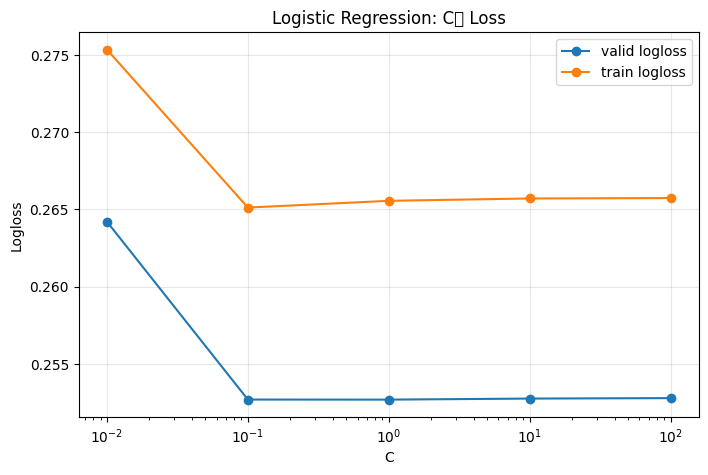

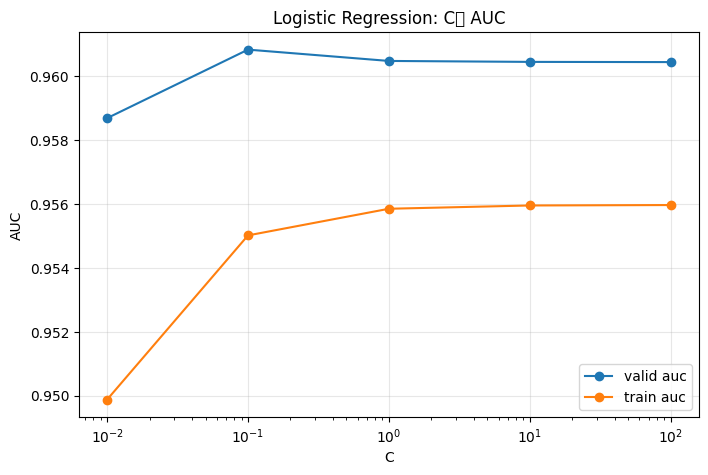

In [39]:
# Logistic Regression 성능 곡선
lr_plot_df = lr_search_df.sort_values("C").reset_index(drop=True)

plt.figure(figsize=(8, 5))
plt.semilogx(lr_plot_df["C"], lr_plot_df["valid_logloss"], marker="o", label="valid logloss")
plt.semilogx(lr_plot_df["C"], lr_plot_df["train_logloss"], marker="o", label="train logloss")
plt.xlabel("C")
plt.ylabel("Logloss")
plt.title("Logistic Regression: C별 Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.semilogx(lr_plot_df["C"], lr_plot_df["valid_auc"], marker="o", label="valid auc")
plt.semilogx(lr_plot_df["C"], lr_plot_df["train_auc"], marker="o", label="train auc")
plt.xlabel("C")
plt.ylabel("AUC")
plt.title("Logistic Regression: C별 AUC")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

,feature,coef,abs_coef
6,num__days_since_last_tx,3.801752,3.801752
27,num__inactive_streak_max,-1.058835,1.058835
9,num__last_cancel,0.954029,0.954029
8,num__last_auto_renew,-0.735898,0.735898
16,num__active_days_30,-0.606965,0.606965
38,cat__city_3,0.480687,0.480687
51,cat__city_16,0.424189,0.424189
29,num__listen_secs_per_paid_amount_30,0.392092,0.392092
49,cat__city_14,-0.389853,0.389853
61,cat__registered_via_9,-0.361808,0.361808


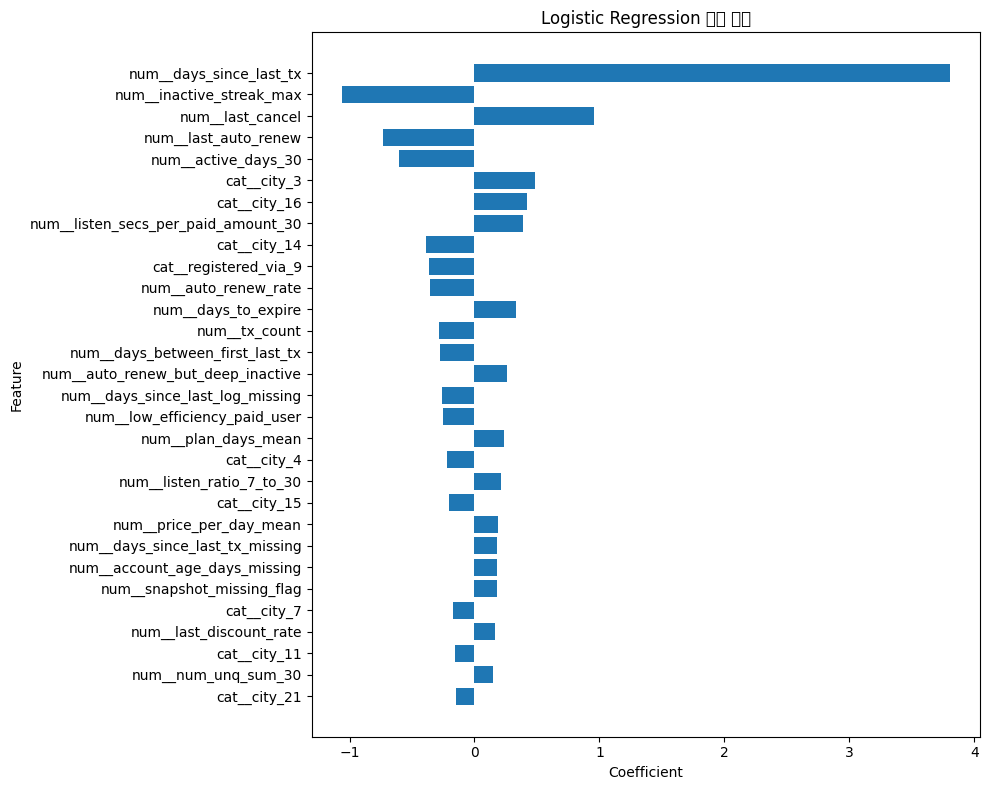

In [29]:
# Logistic Regression 계수 확인
lr_feature_names = best_lr_model.named_steps["preprocessor"].get_feature_names_out()
lr_coef = best_lr_model.named_steps["model"].coef_.ravel()

lr_coef_df = pd.DataFrame({
    "feature": lr_feature_names,
    "coef": lr_coef
})
lr_coef_df["abs_coef"] = lr_coef_df["coef"].abs()
lr_coef_top = lr_coef_df.sort_values("abs_coef", ascending=False).head(30)

display(lr_coef_top[["feature", "coef", "abs_coef"]])

plt.figure(figsize=(10, 8))
plt.barh(lr_coef_top["feature"][::-1], lr_coef_top["coef"][::-1])
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Logistic Regression 상위 계수")
plt.tight_layout()
plt.show()

lr_result = lr_search_df.iloc[0].to_dict()
lr_result["model"] = f"Logistic Regression (best C={best_lr_c})"

## 2. 랜덤포레스트(Random Forest)

In [30]:
# ------------------------------
# Random Forest
# ------------------------------
rf_model = Pipeline(steps=[
    ("preprocessor", build_preprocessor(scale_numeric=False)),
    ("model", RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=SEED,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_result, rf_train_prob, rf_valid_prob = evaluate_binary_model(
    rf_model, X_train, y_train, X_valid, y_valid, model_name="Random Forest"
)

rf_feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()
rf_importance = rf_model.named_steps["model"].feature_importances_

rf_imp_df = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": rf_importance
}).sort_values("importance", ascending=False)

print("[Random Forest top importance]")
display(rf_imp_df.head(30))

Random Forest
{'model': 'Random Forest', 'train_auc': 0.9990351833619112, 'valid_auc': 0.985660954311538, 'train_logloss': 0.062013500510153474, 'valid_logloss': 0.11350133166545154, 'train_f1': 0.9641103135625236, 'valid_f1': 0.8358686949559647, 'train_acc': 0.9905, 'valid_acc': 0.959, 'auc_gap': 0.01337422905037322, 'f1_gap': 0.12824161860655892, 'logloss_gap': 0.051487831155298064}

[valid confusion matrix]
[[4273   86]
 [ 119  522]]

[valid classification report]
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      4359
           1       0.86      0.81      0.84       641

    accuracy                           0.96      5000
   macro avg       0.92      0.90      0.91      5000
weighted avg       0.96      0.96      0.96      5000

[Random Forest top importance]


,feature,importance
6,num__days_since_last_tx,0.182543
5,num__days_between_first_last_tx,0.116852
8,num__last_auto_renew,0.071762
26,num__days_since_last_log,0.071739
11,num__auto_renew_rate,0.062842
4,num__tx_count,0.061176
9,num__last_cancel,0.046343
32,num__auto_renew_but_deep_inactive,0.031278
12,num__plan_days_mean,0.028690
29,num__listen_secs_per_paid_amount_30,0.024964


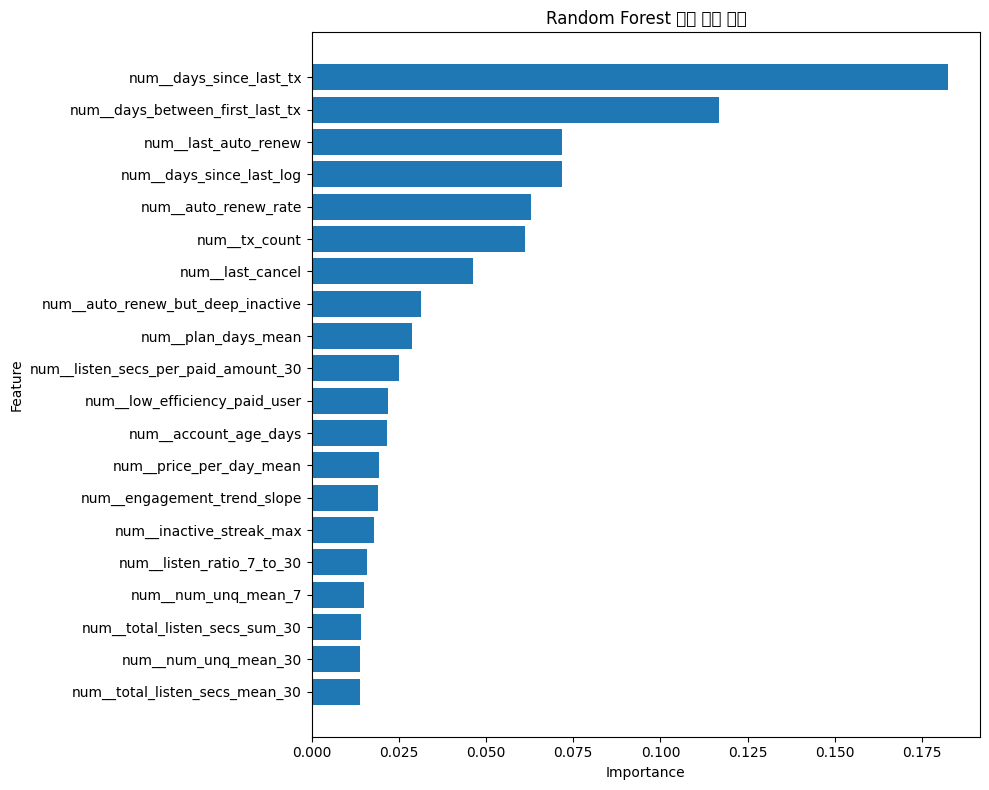

In [31]:
plt.figure(figsize=(10, 8))
rf_top = rf_imp_df.head(20).sort_values("importance", ascending=True)
plt.barh(rf_top["feature"], rf_top["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest 상위 중요 변수")
plt.tight_layout()
plt.show()

## 3. 부스팅 계열 모델

### LightGBM

In [32]:
from lightgbm import LGBMClassifier

X_train_lgb = X_train.copy()
X_valid_lgb = X_valid.copy()

for c in cat_cols:
    X_train_lgb[c] = X_train_lgb[c].astype("category")
    X_valid_lgb[c] = X_valid_lgb[c].astype("category")

lgb_model = LGBMClassifier(
    objective="binary",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED
)

lgb_model.fit(
    X_train_lgb, y_train,
    eval_set=[(X_train_lgb, y_train), (X_valid_lgb, y_valid)],
    eval_metric=["auc", "binary_logloss"],
    categorical_feature=cat_cols
)

lgb_result, lgb_train_prob, lgb_valid_prob = evaluate_binary_model(
    lgb_model, X_train_lgb, y_train, X_valid_lgb, y_valid, model_name="LightGBM"
)

lgb_imp = get_top_importance(lgb_model, X_train_lgb.columns, "LightGBM")
lgb_evals_result = lgb_model.evals_result_

[LightGBM] [Info] Number of positive: 2564, number of negative: 17436
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002976 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4058
[LightGBM] [Info] Number of data points in the train set: 20000, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.128200 -> initscore=-1.916968
[LightGBM] [Info] Start training from score -1.916968
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

,feature,importance
8,days_since_last_tx,717
7,days_between_first_last_tx,513
28,days_since_last_log,427
5,account_age_days,408
30,engagement_trend_slope,357
22,skip_ratio,264
23,completion_score,262
6,tx_count,256
3,bd_clean,238
21,num_unq_sum_30,227


### CatBoost

In [33]:
from catboost import CatBoostClassifier

X_train_cat = X_train.copy()
X_valid_cat = X_valid.copy()

for c in cat_cols:
    X_train_cat[c] = X_train_cat[c].astype(str).fillna("MISSING")
    X_valid_cat[c] = X_valid_cat[c].astype(str).fillna("MISSING")

cat_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    custom_metric=["Logloss"],
    iterations=500,
    learning_rate=0.03,
    depth=6,
    random_seed=SEED,
    verbose=100
)

cat_model.fit(
    X_train_cat, y_train,
    eval_set=(X_valid_cat, y_valid),
    cat_features=cat_cols,
    use_best_model=True
)

cat_result, cat_train_prob, cat_valid_prob = evaluate_binary_model(
    cat_model, X_train_cat, y_train, X_valid_cat, y_valid, model_name="CatBoost"
)

cat_imp = get_top_importance(cat_model, X_train_cat.columns, "CatBoost")
cat_evals_result = cat_model.get_evals_result()

0:	test: 0.9300695	best: 0.9300695 (0)	total: 197ms	remaining: 1m 38s
100:	test: 0.9826181	best: 0.9826181 (99)	total: 7.49s	remaining: 29.6s
200:	test: 0.9846478	best: 0.9846653 (197)	total: 13.7s	remaining: 20.4s
300:	test: 0.9851309	best: 0.9851520 (298)	total: 19.9s	remaining: 13.1s
400:	test: 0.9856481	best: 0.9856567 (399)	total: 26.9s	remaining: 6.64s
499:	test: 0.9858041	best: 0.9858324 (493)	total: 35.6s	remaining: 0us

bestTest = 0.9858323858
bestIteration = 493

Shrink model to first 494 iterations.
CatBoost
{'model': 'CatBoost', 'train_auc': 0.9912175470157141, 'valid_auc': 0.9858323858074762, 'train_logloss': 0.07994817169179692, 'valid_logloss': 0.1001036992046622, 'train_f1': 0.8856735276136132, 'valid_f1': 0.817347789824854, 'train_acc': 0.97195, 'valid_acc': 0.9562, 'auc_gap': 0.005385161208237843, 'f1_gap': 0.06832573778875917, 'logloss_gap': 0.02015552751286527}

[valid confusion matrix]
[[4291   68]
 [ 151  490]]

[valid classification report]
              precisio

,feature,importance
8,days_since_last_tx,43.984476
7,days_between_first_last_tx,11.567314
13,auto_renew_rate,8.851039
28,days_since_last_log,6.393626
10,last_auto_renew,6.042172
11,last_cancel,3.853614
6,tx_count,2.990843
15,price_per_day_mean,1.624297
29,inactive_streak_max,1.366316
30,engagement_trend_slope,1.243707


### XGBoost

In [34]:
from xgboost import XGBClassifier

X_train_xgb = X_train.copy()
X_valid_xgb = X_valid.copy()

for c in cat_cols:
    full = pd.concat([X_train_xgb[c], X_valid_xgb[c]], axis=0).astype("category")
    categories = full.cat.categories
    X_train_xgb[c] = pd.Categorical(X_train_xgb[c], categories=categories).codes
    X_valid_xgb[c] = pd.Categorical(X_valid_xgb[c], categories=categories).codes

X_train_xgb = X_train_xgb.fillna(-999)
X_valid_xgb = X_valid_xgb.fillna(-999)

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric=["auc", "logloss"],
    random_state=SEED
)

xgb_model.fit(
    X_train_xgb, y_train,
    eval_set=[(X_train_xgb, y_train), (X_valid_xgb, y_valid)],
    verbose=100
)

xgb_result, xgb_train_prob, xgb_valid_prob = evaluate_binary_model(
    xgb_model, X_train_xgb, y_train, X_valid_xgb, y_valid, model_name="XGBoost"
)

xgb_imp = get_top_importance(xgb_model, X_train_xgb.columns, "XGBoost")
xgb_evals_result = xgb_model.evals_result()

[0]	validation_0-auc:0.95942	validation_0-logloss:0.36220	validation_1-auc:0.96460	validation_1-logloss:0.36292
[100]	validation_0-auc:0.98926	validation_0-logloss:0.09555	validation_1-auc:0.98665	validation_1-logloss:0.10719
[200]	validation_0-auc:0.99334	validation_0-logloss:0.07278	validation_1-auc:0.98683	validation_1-logloss:0.09777
[300]	validation_0-auc:0.99566	validation_0-logloss:0.06077	validation_1-auc:0.98707	validation_1-logloss:0.09621
[400]	validation_0-auc:0.99713	validation_0-logloss:0.05209	validation_1-auc:0.98682	validation_1-logloss:0.09660
[499]	validation_0-auc:0.99813	validation_0-logloss:0.04523	validation_1-auc:0.98665	validation_1-logloss:0.09707
XGBoost
{'model': 'XGBoost', 'train_auc': 0.9981269140648625, 'valid_auc': 0.9866462380449795, 'train_logloss': 0.045234164022043874, 'valid_logloss': 0.09706657962104155, 'train_f1': 0.9551166965888689, 'valid_f1': 0.8285479901558654, 'train_acc': 0.98875, 'valid_acc': 0.9582, 'auc_gap': 0.011480676019883007, 'f1_ga

,feature,importance
10,last_auto_renew,0.276674
8,days_since_last_tx,0.155954
11,last_cancel,0.117660
31,listen_secs_per_paid_amount_30,0.070331
7,days_between_first_last_tx,0.050220
28,days_since_last_log,0.035465
13,auto_renew_rate,0.027784
12,last_discount_rate,0.026205
6,tx_count,0.025656
34,auto_renew_but_deep_inactive,0.020306


### 로스값 그래프

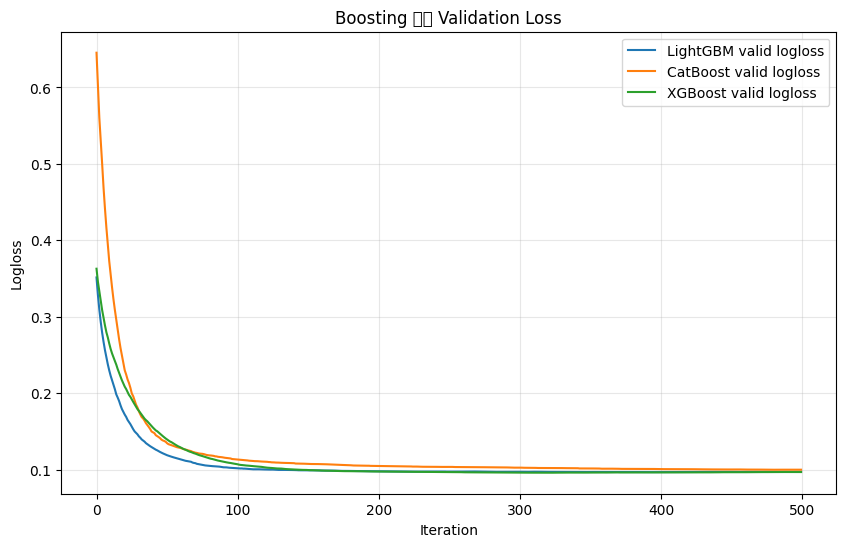

,model,last_valid_logloss
2,XGBoost,0.097067
0,LightGBM,0.097490
1,CatBoost,0.100127


In [35]:
def _extract_metric_from_history(history, split_candidates, metric_candidates):
    if history is None:
        return None
    for split_key in split_candidates:
        if split_key in history:
            for metric_key in metric_candidates:
                if metric_key in history[split_key]:
                    return history[split_key][metric_key]
    return None

lgb_valid_loss = _extract_metric_from_history(
    lgb_evals_result,
    split_candidates=["valid_1", "valid"],
    metric_candidates=["binary_logloss", "logloss", "Logloss"]
)

cat_valid_loss = _extract_metric_from_history(
    cat_evals_result,
    split_candidates=["validation", "validation_0", "valid"],
    metric_candidates=["Logloss", "logloss", "binary_logloss"]
)

xgb_valid_loss = _extract_metric_from_history(
    xgb_evals_result,
    split_candidates=["validation_1", "validation"],
    metric_candidates=["logloss", "Logloss", "binary_logloss"]
)

plt.figure(figsize=(10, 6))
if lgb_valid_loss is not None:
    plt.plot(lgb_valid_loss, label="LightGBM valid logloss")
if cat_valid_loss is not None:
    plt.plot(cat_valid_loss, label="CatBoost valid logloss")
if xgb_valid_loss is not None:
    plt.plot(xgb_valid_loss, label="XGBoost valid logloss")

plt.xlabel("Iteration")
plt.ylabel("Logloss")
plt.title("Boosting 모델 Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

loss_summary = pd.DataFrame({
    "model": ["LightGBM", "CatBoost", "XGBoost"],
    "last_valid_logloss": [
        lgb_valid_loss[-1] if lgb_valid_loss is not None else np.nan,
        cat_valid_loss[-1] if cat_valid_loss is not None else np.nan,
        xgb_valid_loss[-1] if xgb_valid_loss is not None else np.nan,
    ]
}).sort_values("last_valid_logloss")

display(loss_summary)

# 모델 비교

In [36]:
results_df = pd.DataFrame([
    lr_result,
    rf_result,
    lgb_result,
    cat_result,
    xgb_result
]).sort_values(["valid_auc", "valid_logloss"], ascending=[False, True]).reset_index(drop=True)

display(results_df[[
    "model",
    "train_auc", "valid_auc",
    "train_logloss", "valid_logloss",
    "train_f1", "valid_f1",
    "train_acc", "valid_acc",
    "auc_gap", "logloss_gap"
]])

,model,train_auc,valid_auc,train_logloss,valid_logloss,train_f1,valid_f1,train_acc,valid_acc,auc_gap,logloss_gap
0,XGBoost,0.998127,0.986646,0.045234,0.097067,0.955117,0.828548,0.98875,0.9582,0.011481,0.051832
1,LightGBM,0.995847,0.986149,0.059597,0.097490,0.921254,0.829630,0.98040,0.9586,0.009698,0.037893
2,CatBoost,0.991218,0.985832,0.079948,0.100104,0.885674,0.817348,0.97195,0.9562,0.005385,0.020156
3,Random Forest,0.999035,0.985661,0.062014,0.113501,0.964110,0.835869,0.99050,0.9590,0.013374,0.051488
4,Logistic Regression (best C=0.1),0.955020,0.960840,0.265120,0.252693,0.729269,0.728468,0.91740,0.9174,-0.005820,-0.012427


## 앙상블

In [37]:
def evaluate_ensemble_probs(y_true, prob, threshold=0.5, name="ensemble"):
    pred = (prob >= threshold).astype(int)

    result = {
        "model": name,
        "auc": roc_auc_score(y_true, prob),
        "logloss": log_loss(y_true, prob, labels=[0, 1]),
        "f1": f1_score(y_true, pred),
        "acc": accuracy_score(y_true, pred)
    }

    print("=" * 60)
    print(name)
    print(result)
    print("\n[valid confusion matrix]")
    print(confusion_matrix(y_true, pred))
    print("\n[valid classification report]")
    print(classification_report(y_true, pred))

    return result

# 기본 가중치
w_lgb, w_cat, w_xgb = 0.35, 0.40, 0.25

ensemble_valid_prob = (
    w_lgb * lgb_valid_prob +
    w_cat * cat_valid_prob +
    w_xgb * xgb_valid_prob
)

ensemble_result = evaluate_ensemble_probs(
    y_valid,
    ensemble_valid_prob,
    threshold=0.5,
    name="Weighted Soft Voting"
)

# 간단 가중치 탐색
weight_results = []
for w1 in np.arange(0.0, 1.01, 0.1):
    for w2 in np.arange(0.0, 1.01 - w1, 0.1):
        w3 = round(1.0 - w1 - w2, 10)
        if w3 < 0:
            continue
        prob = w1 * lgb_valid_prob + w2 * cat_valid_prob + w3 * xgb_valid_prob
        auc = roc_auc_score(y_valid, prob)
        ll = log_loss(y_valid, prob, labels=[0, 1])
        weight_results.append({
            "w_lgb": round(w1, 2),
            "w_cat": round(w2, 2),
            "w_xgb": round(w3, 2),
            "valid_auc": auc,
            "valid_logloss": ll
        })

weight_df = pd.DataFrame(weight_results).sort_values(
    ["valid_auc", "valid_logloss"], ascending=[False, True]
)
display(weight_df.head(10))

best = weight_df.iloc[0]
best_prob = (
    best["w_lgb"] * lgb_valid_prob +
    best["w_cat"] * cat_valid_prob +
    best["w_xgb"] * xgb_valid_prob
)

best_ensemble_result = evaluate_ensemble_probs(
    y_valid,
    best_prob,
    threshold=0.5,
    name="Best Weighted Soft Voting"
)

Weighted Soft Voting
{'model': 'Weighted Soft Voting', 'auc': 0.9867095853827271, 'logloss': 0.09647031889557124, 'f1': 0.8283828382838284, 'acc': 0.9584}

[valid confusion matrix]
[[4290   69]
 [ 139  502]]

[valid classification report]
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      4359
           1       0.88      0.78      0.83       641

    accuracy                           0.96      5000
   macro avg       0.92      0.88      0.90      5000
weighted avg       0.96      0.96      0.96      5000



,w_lgb,w_cat,w_xgb,valid_auc,valid_logloss
13,0.1,0.2,0.7,0.986817,0.096206
23,0.2,0.2,0.6,0.986810,0.096024
24,0.2,0.3,0.5,0.986809,0.096140
22,0.2,0.1,0.7,0.986806,0.096054
32,0.3,0.2,0.5,0.986805,0.095948
14,0.1,0.3,0.6,0.986805,0.096264
3,0.0,0.3,0.7,0.986804,0.096501
12,0.1,0.1,0.8,0.986792,0.096304
31,0.3,0.1,0.6,0.986788,0.095918
33,0.3,0.3,0.4,0.986787,0.096119


Best Weighted Soft Voting
{'model': 'Best Weighted Soft Voting', 'auc': 0.9868165958572274, 'logloss': 0.09620642153757224, 'f1': 0.8305921052631579, 'acc': 0.9588}

[valid confusion matrix]
[[4289   70]
 [ 136  505]]

[valid classification report]
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      4359
           1       0.88      0.79      0.83       641

    accuracy                           0.96      5000
   macro avg       0.92      0.89      0.90      5000
weighted avg       0.96      0.96      0.96      5000



# 10000개 데이터셋에 대한 예측율

In [43]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from kkbox_feature_engineering_clean import build_feature_table

In [45]:
train_members = pd.read_csv(r"C:\dev\project\project02\Data\total_data_10000\train_members.csv")
transactions = pd.read_csv(r"C:\dev\project\project02\Data\total_data_10000\transactions.csv")
user_logs = pd.read_csv(r"C:\dev\project\project02\Data\total_data_10000\user_logs_aug.csv")

In [47]:
print("train_members 행 수:", len(train_members))
print("train_members 고유 msno 수:", train_members["msno"].nunique())

print("transactions 행 수:", len(transactions))
print("transactions 고유 msno 수:", transactions["msno"].nunique())

print("user_logs 행 수:", len(user_logs))
print("user_logs 고유 msno 수:", user_logs["msno"].nunique())

print("train_final 행 수:", len(train_final))
print("train_final 고유 msno 수:", train_final["msno"].nunique())

train_members 행 수: 10000
train_members 고유 msno 수: 10000
transactions 행 수: 184226
transactions 고유 msno 수: 10000
user_logs 행 수: 3844281
user_logs 고유 msno 수: 10000
train_final 행 수: 25000
train_final 고유 msno 수: 25000


In [48]:
members_ids = set(train_members["msno"].dropna().unique())
tx_ids = set(transactions["msno"].dropna().unique())
log_ids = set(user_logs["msno"].dropna().unique())

raw_test_ids = members_ids | tx_ids | log_ids
train_final_ids = set(train_final["msno"].dropna().unique())

print("raw_test_ids 수:", len(raw_test_ids))
print("train_final_ids 수:", len(train_final_ids))

raw_test_ids 수: 10000
train_final_ids 수: 25000


In [49]:
overlap_ids = train_final_ids & raw_test_ids
only_in_train_final = train_final_ids - raw_test_ids
only_in_raw_test = raw_test_ids - train_final_ids

print("겹치는 ID 수:", len(overlap_ids))
print("train_final에만 있는 ID 수:", len(only_in_train_final))
print("raw 데이터에만 있는 ID 수:", len(only_in_raw_test))

겹치는 ID 수: 641
train_final에만 있는 ID 수: 24359
raw 데이터에만 있는 ID 수: 9359


In [51]:
from kkbox_feature_engineering_clean import build_feature_table

test_final = build_feature_table(
    train_members=train_members,
    transactions=transactions,
    user_logs=user_logs
)

print("test_final 행 수:", len(test_final))
print("test_final 고유 msno 수:", test_final["msno"].nunique())

test_final 행 수: 10000
test_final 고유 msno 수: 10000


In [52]:
train_final_ids = set(train_final["msno"].dropna().unique())
test_final_ids = set(test_final["msno"].dropna().unique())

overlap_ids = train_final_ids & test_final_ids

print("train_final ID 수:", len(train_final_ids))
print("test_final ID 수:", len(test_final_ids))
print("겹치는 ID 수:", len(overlap_ids))
print("완전히 동일한가?", train_final_ids == test_final_ids)

train_final ID 수: 25000
test_final ID 수: 10000
겹치는 ID 수: 641
완전히 동일한가? False


In [53]:
test_final_clean = test_final[~test_final["msno"].isin(train_final["msno"])].copy()

print("제거 전 test_final 행 수:", len(test_final))
print("제거 후 test_final_clean 행 수:", len(test_final_clean))
print("제거 후 고유 msno 수:", test_final_clean["msno"].nunique())

제거 전 test_final 행 수: 10000
제거 후 test_final_clean 행 수: 9359
제거 후 고유 msno 수: 9359
